<a href="https://colab.research.google.com/github/bw123111/csci547_ML/blob/main/assignments/kaggle_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kaggle competition #2


You've learned a great deal about supervised learning and now it's time to bring together all that you've learned. You will be competing in a 'Kaggle Competition' along with the rest of the class! Your goal is to predict the 'target' based on the features provided.  While you will be asked to take certain steps along the way to your submission, you're encouraged to try creative solutions to this problem and your choices are wide open for you to make your decisions on how to best make the predictions.

The competition is hosted [here](https://www.kaggle.com/competitions/umt-csci-447-547-fall-2025-competition). Please follow the directions on kaggle to submit your predictions.


**The Data**. This is a regression problem with 20 numerical predictors and 1 target. You have access to 400 training samples, and there are 800 testing samples. You will train your model on the training samples and then make predictions on the 800 testing samples, which you will submit (as a .csv file) to be scored. There is an example testing submission file included to demonstrate how the submission files should look.

**Scoring**. Your performance will be judged using mean-squared error (MSE).  You will submit your predictions to kaggle using the submission instructions. The leaderboard will show your performance on half of the testing samples (400 samples), while another 400 remain for "private" testing, and your score on this private set will be revealed at the end of the competition. You will need to achieve a minimum acceptable level of performance to demonstrate proficiency with using these supervised learning techniques.  

Beyond that, it's an open competition and scoring in the top three places of the private leaderboard will result in \textbf{5 bonus points in this assignment} (and the pride of the class!). Note: the Kaggle leaderboard has a public and private component. The public component is viewable throughout the competition, but the private leaderboard is revealed at the end. When you make a submission, you immediately see your submission on the public leaderboard, but that only represents scoring on a fraction of the total collection of test data, the rest remains hidden until the end of the competition to prevent overfitting to the test data through repeated submissions. You will be be allowed to hand-select two eligible submissions for private score, or by default your best two public scoring submissions will be selected for private scoring.

**Grade** Your grade on this will be based on both your performance (50 points) and the notebook you submit (40 points).  As always, an additional 10 points are allocated to presentation quality. For your notebook, your grade will depend on the following:

### Guidance:
1. **Preprocessing**. You may need to preprocess the data for some of these models to perform well (scaling inputs or reducing dimensionality). Some of this preprocessing may differ from model to model to achieve the best performance. A helpful tool for creating such preprocessing and model fitting pipelines is the sklearn `pipeline` module which lets you group a series of processing steps together.
2. **Hyperparameters**. Hyperparameters may need to be tuned for some of the models you use. You may want to perform hyperparameter tuning for some of the models. `optuna` is a great framework for this, if you want to try it out. If you experiment with different hyperparameters that include many model runs, you may want to apply them to a small subsample of your overall data before running it on the larger training set to be time efficient (if you do, just make sure to ensure your selected subset is representative of the rest of your data).
3. **Validation data**. You're encouraged to create your own validation dataset for comparing model performance; without this, there's a significant likelihood of overfitting to the data. A common choice of the split is 80% training, 20% validation. Before you make your final predictions on the test data, be sure to retrain your model on the entire dataset.


#**Data Import and Exploration**

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline

In [88]:
train = pd.read_csv('https://raw.githubusercontent.com/bw123111/csci547_ML/refs/heads/main/assignments/data/Kaggle_competition2/train.csv')
test = pd.read_csv('https://raw.githubusercontent.com/bw123111/csci547_ML/refs/heads/main/assignments/data/Kaggle_competition2/test.csv')

print(f"Train shape: {train.shape} \nTest shape: {test.shape}")
train.head()

Train shape: (400, 22) 
Test shape: (800, 21)


,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f12,f13,f14,f15,f16,f17,f18,f19,f20,target
0,1,0.813120,-0.317922,0.027886,2.966993,1.792626,1.639461,1.038417,-1.265553,2.737895,...,2.074784,-0.549459,0.588724,0.670610,0.102525,1.963463,-0.349565,-0.294764,-0.206112,-18.759727
1,2,1.187370,0.574752,0.480094,1.003127,1.743455,1.653923,0.289389,1.758154,1.447072,...,0.904899,0.936627,0.692230,0.631463,1.022266,2.211432,-0.318560,0.696366,0.693999,8.082223
2,3,0.713207,-0.061996,0.423746,0.111901,1.763365,1.651579,1.026891,1.283781,1.116797,...,1.581493,1.151487,0.213017,0.766878,1.003003,1.824628,1.248738,NaN,0.600792,2.961315
3,4,0.779316,0.687488,0.388627,1.343889,1.743500,1.641686,-0.670589,0.135970,1.553194,...,1.995739,0.650913,0.925546,0.657044,0.558577,1.915205,2.763816,1.665433,0.397841,-0.710178
4,5,0.674119,-0.286842,0.386524,2.416830,1.787492,1.636464,1.782221,0.722959,2.030776,...,0.485689,-1.000375,0.970572,0.900548,0.638401,1.893995,-2.186096,1.838846,1.070571,5.328069


In [89]:
train.describe()

,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f12,f13,f14,f15,f16,f17,f18,f19,f20,target
count,400.000000,395.000000,398.000000,397.000000,397.000000,393.000000,398.000000,396.000000,397.000000,397.000000,...,397.000000,394.000000,395.000000,400.000000,395.000000,396.000000,398.000000,397.000000,394.000000,400.000000
mean,200.500000,0.929817,0.103775,0.399106,0.624035,1.733973,1.658296,0.674185,1.528509,1.506796,...,1.215997,0.416822,0.575530,0.747083,0.798745,1.994602,0.557108,1.206750,0.469494,-1.130048
std,115.614301,0.230155,0.443145,0.181493,1.356035,0.050163,0.052309,0.938464,1.343001,0.655062,...,0.984864,1.095934,0.212071,0.192322,0.363336,1.215101,1.415854,0.777583,0.494618,10.848223
min,1.000000,0.283227,-1.197332,-0.198983,-3.298943,1.601365,1.506374,-2.125939,-2.467309,-0.361726,...,-1.858385,-2.443500,-0.099370,0.115061,-0.164741,-1.437118,-4.529443,-1.292303,-0.873796,-56.422845
25%,100.750000,0.789294,-0.198059,0.267863,-0.305175,1.702095,1.623567,0.054529,0.593326,1.064722,...,0.599725,-0.326329,0.418883,0.619042,0.531878,1.223741,-0.406788,0.692043,0.097671,-5.335921
50%,200.500000,0.946842,0.096516,0.411260,0.506337,1.732611,1.656562,0.643489,1.595760,1.486259,...,1.258694,0.439387,0.578007,0.747589,0.786984,2.009483,0.532240,1.220152,0.458768,-0.510613
75%,300.250000,1.082765,0.413801,0.522271,1.515553,1.765177,1.694608,1.274544,2.495724,1.985032,...,1.903233,1.095831,0.726754,0.880957,1.059191,2.828374,1.502131,1.759239,0.818868,3.934202
max,400.000000,1.588043,1.212879,0.884020,4.304862,1.889694,1.816105,3.260017,5.205119,3.271230,...,3.933328,3.741093,1.069151,1.335387,1.884126,5.748790,4.764340,3.165238,1.743199,36.101080


##**Test data summary**

In [90]:
test.head()

,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20
0,401,0.969811,-0.389490,-0.075381,-1.505691,1.720168,1.735027,1.356886,-1.708672,0.604604,...,2.967954,0.746284,1.301299,0.550946,0.690254,0.223682,1.851455,0.318604,0.762520,0.472288
1,402,1.121796,0.768937,0.362358,-1.123408,1.773125,1.708505,-0.983776,1.381184,0.678767,...,-2.444318,1.238919,0.061478,0.641270,0.961008,0.633535,2.458810,0.983950,2.324804,0.686668
2,403,1.085732,0.207999,0.285440,NaN,1.607725,1.595718,0.561353,0.854037,1.641407,...,2.914548,3.810751,0.350238,0.568409,0.780886,0.792704,1.701120,-2.529507,1.029163,0.591332
3,404,1.079724,0.303261,0.397446,-0.757769,1.723312,1.702758,0.075594,0.862485,1.113665,...,2.071923,2.244971,-0.495614,0.611114,0.795765,1.642672,2.099708,1.441551,1.460350,0.047208
4,405,0.733227,-0.122467,0.517686,1.088353,1.878982,1.655497,1.579678,2.204686,1.893622,...,0.975109,2.274006,-1.562658,0.840123,0.663351,1.527473,2.678541,1.296108,1.211495,0.542183


In [91]:
test.describe()

,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20
count,800.0000,792.000000,793.000000,790.000000,794.000000,796.000000,795.000000,796.000000,788.000000,787.000000,...,793.000000,792.000000,795.000000,790.000000,791.000000,793.000000,792.000000,789.000000,788.000000,789.000000
mean,800.5000,0.922187,0.089932,0.393375,0.741476,1.737368,1.658658,0.695658,1.454017,1.563485,...,0.482627,1.228638,0.421218,0.566846,0.741701,0.784357,1.999208,0.617907,1.223967,0.490811
std,231.0844,0.247038,0.416870,0.181306,1.380126,0.048176,0.056257,0.875495,1.272151,0.649062,...,2.170702,1.019518,1.072719,0.207715,0.207896,0.345019,1.166512,1.369179,0.784717,0.477336
min,401.0000,0.179166,-1.211708,-0.123744,-3.346579,1.593022,1.497201,-2.276049,-2.570132,-0.256511,...,-5.366991,-2.071085,-2.838001,-0.087603,-0.037398,-0.307456,-2.066978,-3.462699,-1.030878,-1.024568
25%,600.7500,0.770882,-0.196616,0.279383,-0.152365,1.705727,1.620881,0.119836,0.666473,1.124636,...,-1.061285,0.555759,-0.307616,0.427330,0.601736,0.566556,1.218908,-0.327380,0.725737,0.190116
50%,800.5000,0.922555,0.101894,0.389584,0.763542,1.737265,1.657115,0.694288,1.428990,1.593320,...,0.485389,1.271342,0.461226,0.566073,0.749983,0.792893,2.000624,0.636303,1.215858,0.489500
75%,1000.2500,1.079115,0.344277,0.502395,1.654228,1.770761,1.695984,1.302362,2.331040,2.006495,...,2.066701,1.906454,1.125098,0.705727,0.881620,1.001793,2.785157,1.491039,1.736114,0.809978
max,1200.0000,1.730196,1.484091,0.921580,5.067383,1.878982,1.819626,3.498136,5.184836,3.840651,...,6.299607,4.983798,4.048099,1.140148,1.393733,1.755410,5.327498,4.873214,3.825004,2.040363


**Boxplots of data covariates**

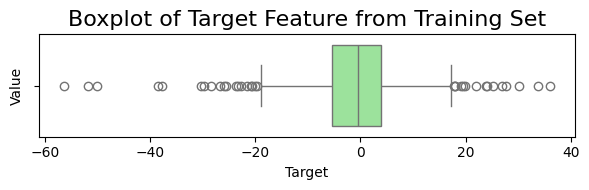

In [92]:
plt.figure(figsize=(6, 2))
sns.boxplot(x='target', data=train, color="lightgreen")
plt.title('Boxplot of Target Feature from Training Set', fontsize=16)
plt.xlabel('Target')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

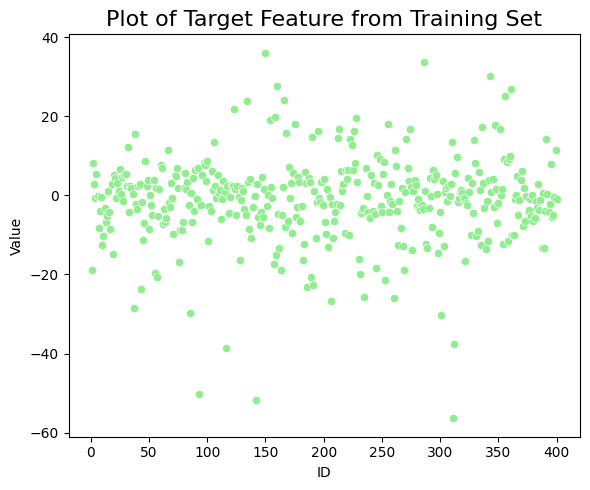

In [93]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='id', y='target', data=train, color="lightgreen")
plt.title('Plot of Target Feature from Training Set', fontsize=16)
plt.xlabel('ID')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

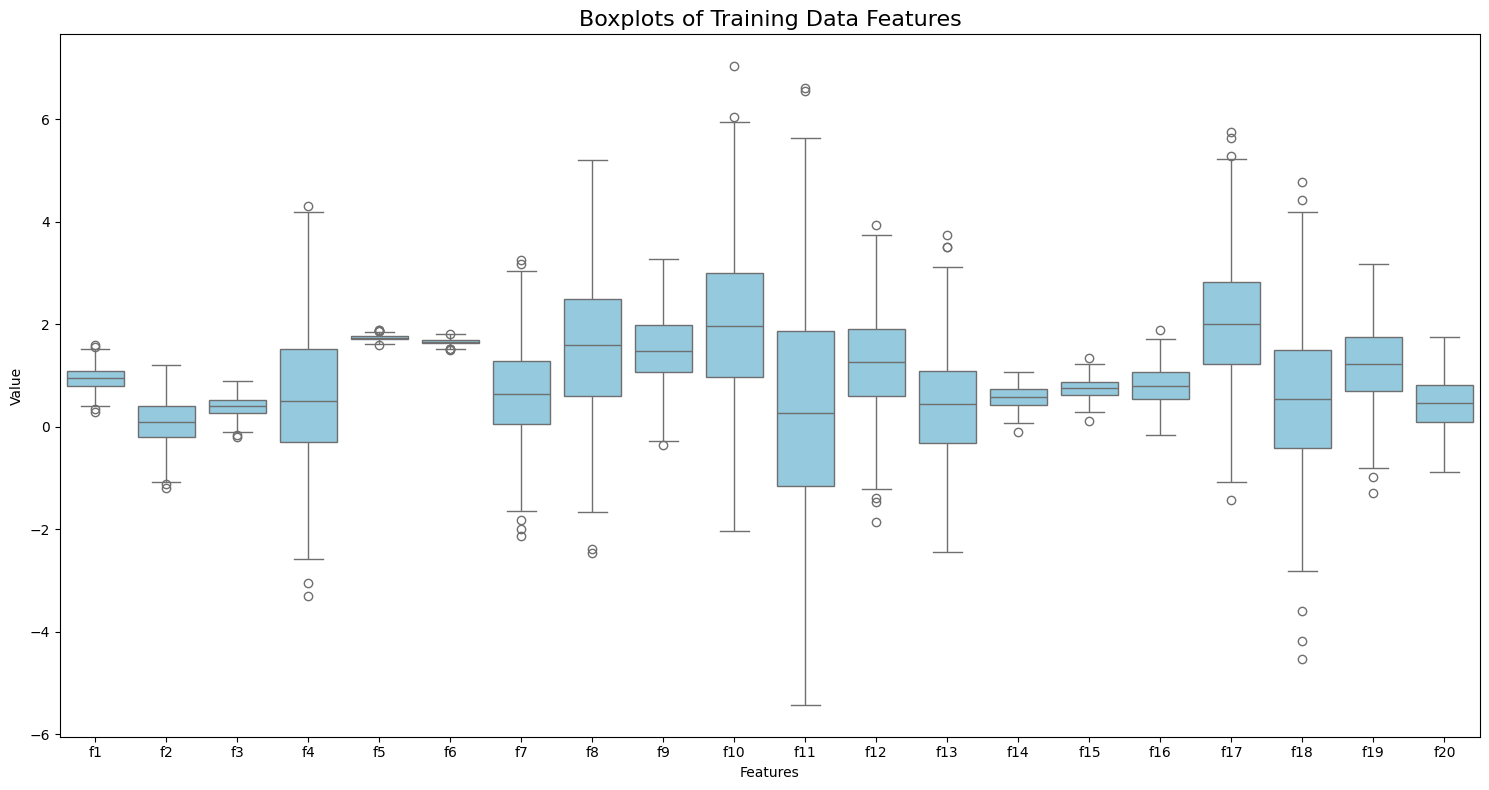

In [94]:
features = train.drop(columns=['id', 'target']).columns

# Melt the DataFrame to long format for plotting of each covariate boxplots on same axes
train_melted = train[features].melt(var_name='feature', value_name='value')

plt.figure(figsize=(15, 8))
sns.boxplot(x='feature', y='value', data=train_melted, color="skyblue")
plt.title('Boxplots of Training Data Features', fontsize=16)
plt.xlabel('Features')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

Correlation of training data features

<Axes: >

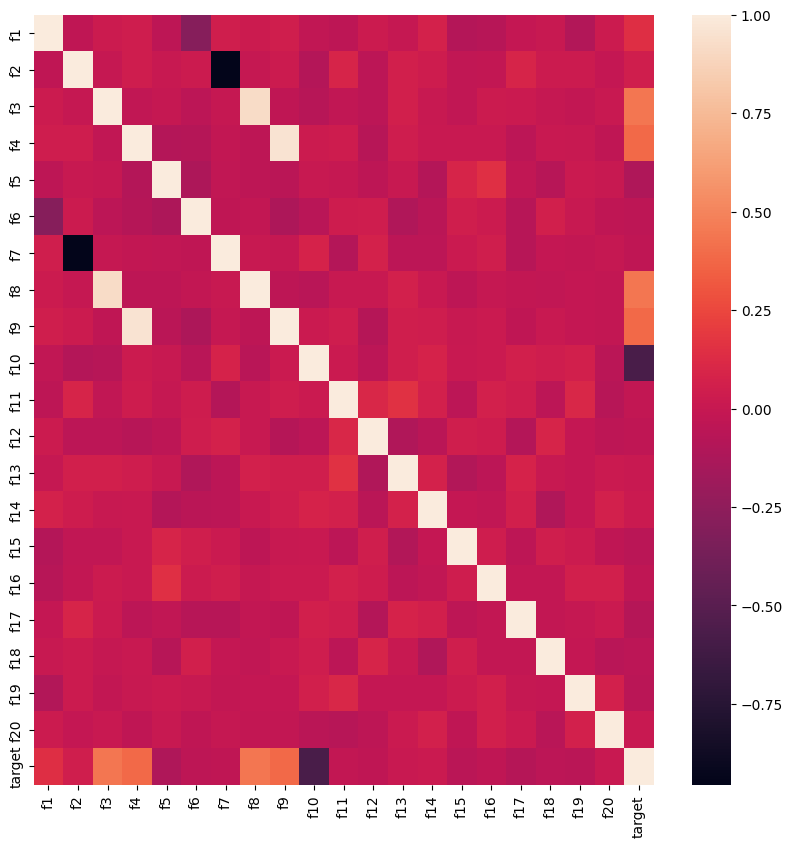

In [95]:
plt.figure(figsize = (10, 10))
sns.heatmap((train.drop(columns=['id'])).corr())

Pairplot training covariates

In [96]:
# sns.pairplot(train.drop(columns=['id']))

Pairplot testing covariates

In [97]:
# sns.pairplot(test.drop(columns=['id']))

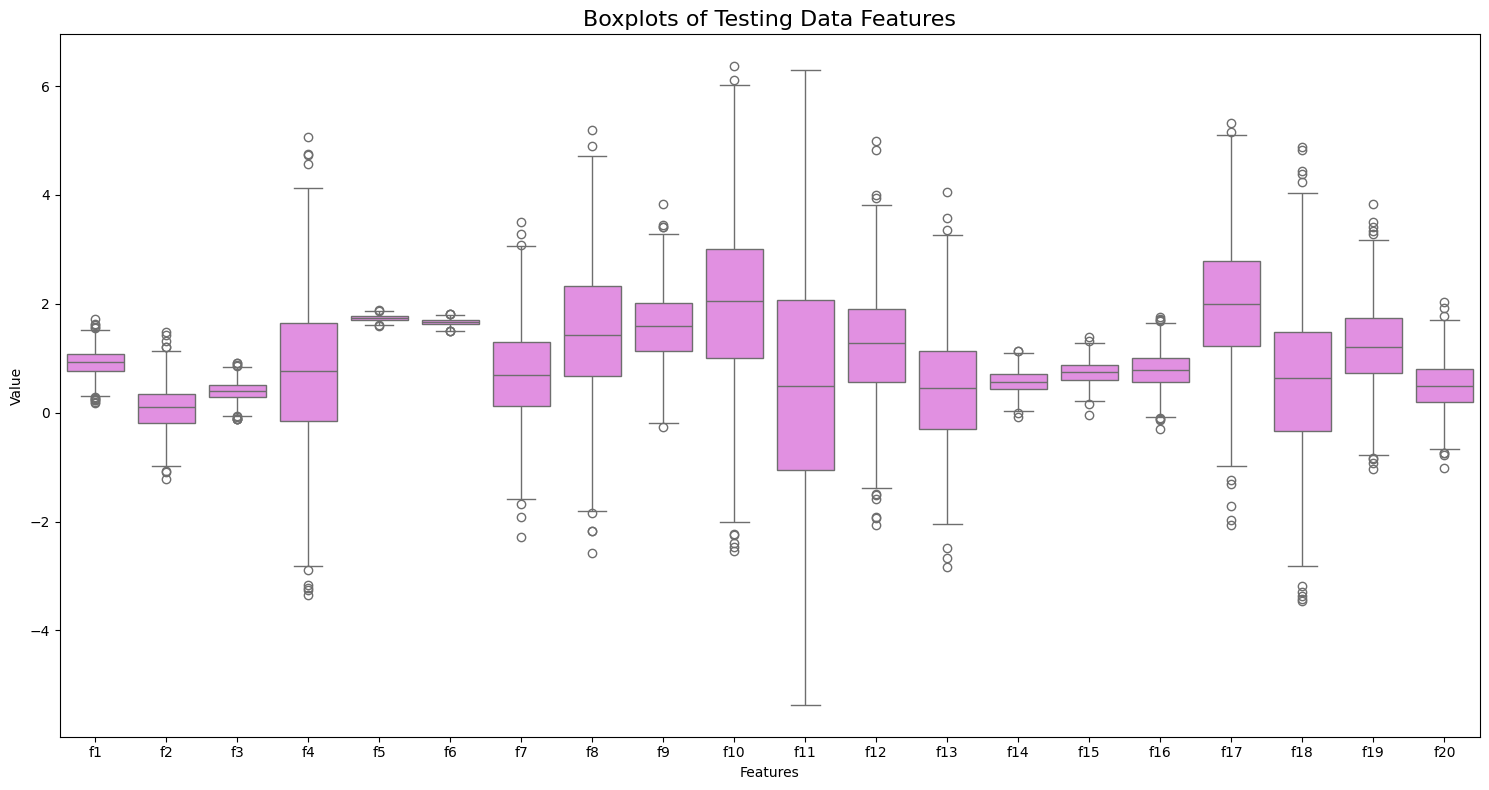

In [98]:
# Melt the DataFrame to long format for plotting of each covariate boxplots on same axes
test_melted = test[features].melt(var_name='feature', value_name='value')

plt.figure(figsize=(15, 8))
sns.boxplot(x='feature', y='value', data=test_melted, color="violet")
plt.title('Boxplots of Testing Data Features', fontsize=16)
plt.xlabel('Features')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

#**Preprocess data**  
### NA Handling


In [99]:
print("train NA's:", train.isna().sum().sum()) # count NA values in entire dataframe
print("test NA's:", test.isna().sum().sum()) # count NA values in entire dataframe

train NA's: 74
test NA's: 166


For optimal results and so that the models will run, we will drop rows with NA. Missing data can cause a model to throw errors or result in decreased accuracy.

In [100]:
train.dropna(inplace=True) # drop rows with NA values
test.dropna(inplace=True) # drop rows with NA values
print(f"Train shape: {train.shape} \nTest shape: {test.shape}")

Train shape: (333, 22) 
Test shape: (648, 21)


In [101]:
print("train NA's:", train.isna().sum().sum()) # count NA values in entire dataframe
print("test NA's:", test.isna().sum().sum()) # count NA values in entire dataframe

train NA's: 0
test NA's: 0


We will drop the id column since this is not a covariate, but an index.

In [102]:
train.drop(columns=['id'], inplace=True)
test.drop(columns=['id'], inplace=True)

### **Train test split**  
to create a validation dataset from the training data. This validation data will be used to fine tune the models after initial training to improve performance.

In [103]:
x_train, x_val, y_train, y_val = train_test_split(train.drop(columns=['target']), train['target'], test_size=0.2, random_state=42)
print("The dimension of X_train is", (x_train.shape))
print("The dimension of X_val is", (x_val.shape))

The dimension of X_train is (266, 20)
The dimension of X_val is (67, 20)


### **Scaling**  
The various covariates/features do not share the same min and max, so we will scale the data for consistency. This will allow the models to perform better.

In [104]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
test = scaler.transform(test)

#**Train 5+ models**  
some options:

Linear regression  
Polynomial regression  
Lasso regression  
Ridge regression  
Decision tree regression  
Random forest regression  
Support vector regression  

Some of these can be experiments with different hyperparameter-tuned versions of the same model


Since we have so many covariates, a model that can handle them seems suitable, such as Lasso, Ridge, and Support Vector regression. Each of these shrinks coefficients or does feature selection to reduce the dimensions modelled.  

Employing Principle Component Analysis, then running another of the regression options above may also work since PCA reduces the dimensions of the dataset.

**I will be using Lasso, Ridge, and Support Vector regression with various hyperparameters**

##Lasso Regression

In [105]:
start = time.perf_counter() # start timer

lasso = Lasso(alpha=1.0)  # init model
lasso.fit(x_train, y_train) # fit model

end = time.perf_counter() # end timer
duration_nonCV_lasso1 = end - start # calculate time elapsed

Hyperparameter Tuning using Cross Validation

In [106]:
start = time.perf_counter() # start timer

# initialize cross validation using various values of alpha
lasso_cv = LassoCV(alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10], random_state = 42)
# fit cross validation
lasso_cv.fit(x_train, y_train)

end = time.perf_counter() # end timer
duration_CV_lasso1 = end - start # calculate time elapsed

In [107]:
# print error scores for lasso
print("Train lasso R squared score:", lasso.score(x_train, y_train))
print("Validation lasso R squared score:", lasso.score(x_val, y_val))
# print error scores for lasso CV
print("\nCV Train lasso R squared score:", lasso_cv.score(x_train, y_train))
print("CV Validation lasso R squared score:", lasso_cv.score(x_val, y_val))
print("Best alpha:", lasso_cv.alpha_)

Train lasso R squared score: 0.6989238908748545
Validation lasso R squared score: 0.6914392253624924

CV Train lasso R squared score: 0.7436315968792524
CV Validation lasso R squared score: 0.6911587502285622
Best alpha: 0.1


Visualize Coefficients

<Axes: title={'center': 'Lasso Coefficients pre-CV'}>

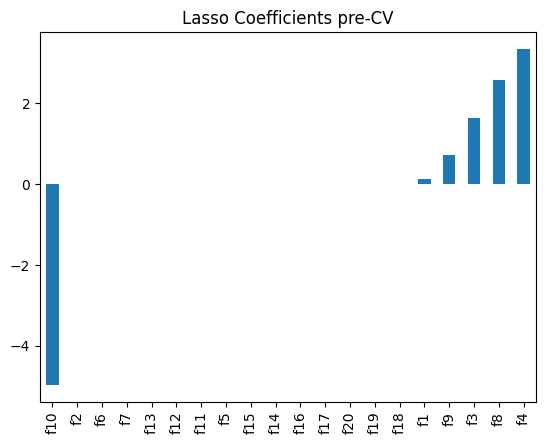

In [108]:
pd.Series(lasso.coef_, features).sort_values(ascending = True).plot(kind = "bar", title = "Lasso Coefficients pre-CV")

<Axes: title={'center': 'Lasso Coefficients post-CV'}>

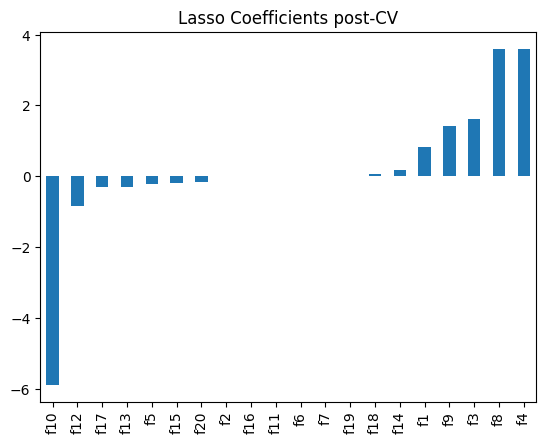

In [109]:
pd.Series(lasso_cv.coef_, features).sort_values(ascending = True).plot(kind = "bar", title = "Lasso Coefficients post-CV")

## Lasso Regression V.2: refining alpha
Since the best alpha was 0.1, I will run the model again with CV alpha values closer to 0.1.

In [110]:
start = time.perf_counter() # start timer

lasso2 = Lasso(alpha=1.0)  # init model
lasso2.fit(x_train, y_train) # fit model

end = time.perf_counter() # end timer
duration_nonCV_lasso2 = end - start # calculate time elapsed

Hyperparameter Tuning using Cross Validation

In [111]:
start = time.perf_counter() # start timer

# initialize cross validation using various values of alpha
lasso_cv2 = LassoCV(alphas = [0.05, 0.075, 0.1, 0.25, 0.5], random_state = 42)
# fit cross validation
lasso_cv2.fit(x_train, y_train)

end = time.perf_counter() # end timer
duration_CV_lasso2 = end - start # calculate time elapsed

In [112]:
# print error scores for lasso
print("Train lasso R squared score:", lasso2.score(x_train, y_train))
print("Validation lasso R squared score:", lasso2.score(x_val, y_val))
# print error scores for lasso CV
print("\nCV Train lasso R squared score:", lasso_cv2.score(x_train, y_train))
print("CV Validation lasso R squared score:", lasso_cv2.score(x_val, y_val))
print("Best alpha:", lasso_cv2.alpha_)

Train lasso R squared score: 0.6989238908748545
Validation lasso R squared score: 0.6914392253624924

CV Train lasso R squared score: 0.7281640497924696
CV Validation lasso R squared score: 0.7029026553862407
Best alpha: 0.5


Visualize Coefficients

<Axes: title={'center': 'Lasso Coefficients pre-CV'}>

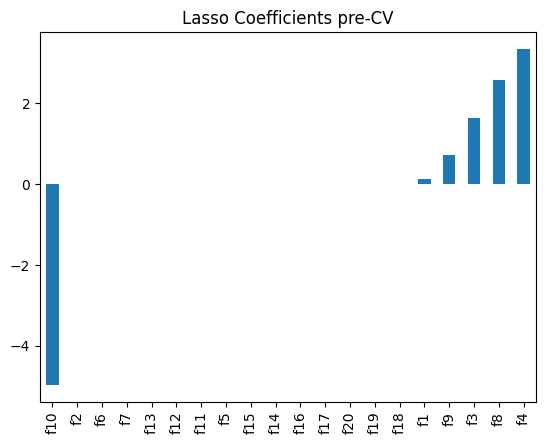

In [113]:
pd.Series(lasso.coef_, features).sort_values(ascending = True).plot(kind = "bar", title = "Lasso Coefficients pre-CV")

<Axes: title={'center': 'Lasso Coefficients post-CV'}>

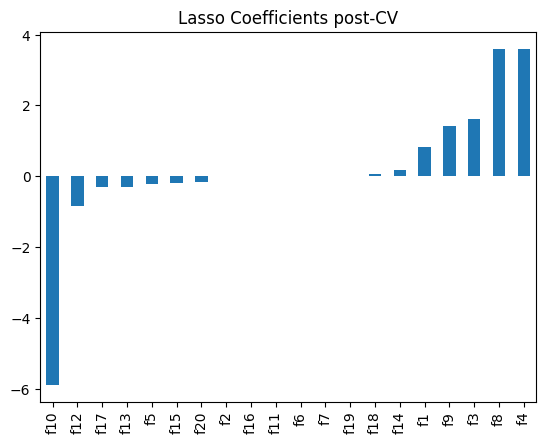

In [114]:
pd.Series(lasso_cv.coef_, features).sort_values(ascending = True).plot(kind = "bar", title = "Lasso Coefficients post-CV")

##Ridge Regression

In [115]:
start = time.perf_counter() # start timer

rr = Ridge(alpha=1.0)  # init model
rr.fit(x_train, y_train) # fit model

end = time.perf_counter() # end timer
duration_nonCV_rr1 = end - start # calculate time elapsed

Hyperparameter Tuning using Cross Validation

In [116]:
start = time.perf_counter() # start timer

# initialize cross validation using various values of alpha
rr_cv = RidgeCV(alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10], scoring = 'r2')
rr_cv.fit(x_train, y_train)

end = time.perf_counter() # end timer
duration_CV_rr1 = end - start # calculate time elapsed

In [117]:
# print error scores for ridge regression
print("Train ridge R squared score:", rr.score(x_train, y_train))
print("Validation ridge R squared score:", rr.score(x_val, y_val))

# print error scores for ridge regression CV
print("\nCV Train ridge R squared score:", rr_cv.score(x_train, y_train))
print("CV Validation ridge R squared score:", rr_cv.score(x_val, y_val))
print("Best alpha:", rr_cv.alpha_)

Train ridge R squared score: 0.7453340144495719
Validation ridge R squared score: 0.6733593937346877

CV Train ridge R squared score: 0.7442753882947789
CV Validation ridge R squared score: 0.679183367385789
Best alpha: 10.0


Visualize Coefficients

<Axes: title={'center': 'Ridge Coefficients Pre-CV'}>

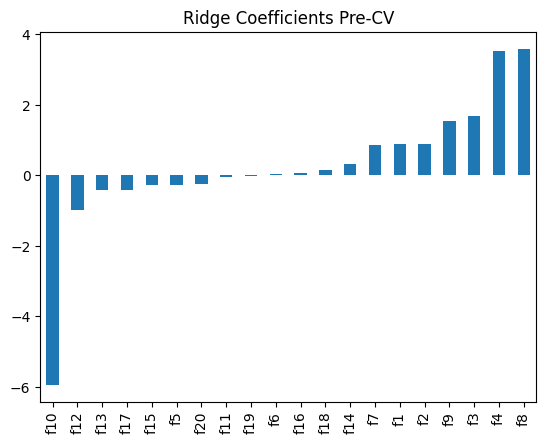

In [118]:
pd.Series(rr.coef_, features).sort_values(ascending = True).plot(kind = "bar", title = "Ridge Coefficients Pre-CV")

<Axes: title={'center': 'Ridge Coefficients post-CV'}>

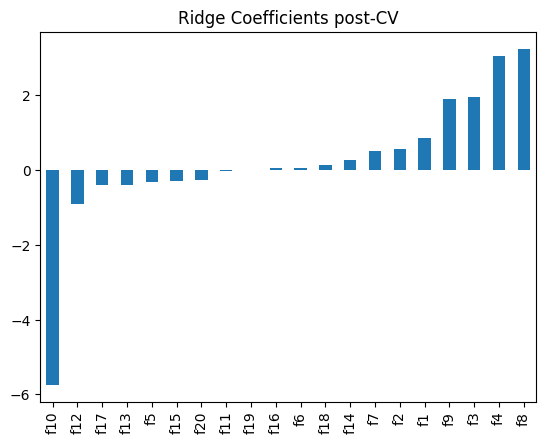

In [119]:
pd.Series(rr_cv.coef_, features).sort_values(ascending = True).plot(kind = "bar", title = "Ridge Coefficients post-CV")

##Ridge Regression V.2: Refining Alpha
This time, the best alpha value is at the edge of the range of alphas that I used in crossvalidation, and it did not perform much better than the non-CV ridge regression. So, we will adjust the values of alpha to be greater in an attempt to fine tune the hyperparameters of this model!

In [120]:
start = time.perf_counter() # start timer

rr2 = Ridge(alpha=1.0)  # init model
rr2.fit(x_train, y_train) # fit model

end = time.perf_counter() # end timer
duration_nonCV_rr2 = end - start # calculate time elapsed

Hyperparameter Tuning using Cross Validation

In [121]:
start = time.perf_counter() # start timer

# initialize cross validation using various values of alpha
rr2_cv = RidgeCV(alphas = [11, 12, 13, 14, 15], scoring = 'neg_mean_squared_error')
rr2_cv.fit(x_train, y_train)

end = time.perf_counter() # end timer
duration_CV_rr2 = end - start # calculate time elapsed

In [122]:
# print error scores for ridge regression
print("Train ridge R squared score:", rr2.score(x_train, y_train))
print("Validation ridge R squared score:", rr2.score(x_val, y_val))

# print error scores for ridge regression CV
print("\nCV Train ridge R squared score:", rr2_cv.score(x_train, y_train))
print("CV Validation ridge R squared score:", rr2_cv.score(x_val, y_val))
print("Best alpha:", rr2_cv.alpha_)

Train ridge R squared score: 0.7453340144495719
Validation ridge R squared score: 0.6733593937346877

CV Train ridge R squared score: 0.7435187172850171
CV Validation ridge R squared score: 0.6804886041983225
Best alpha: 14


Visualize Coefficients

<Axes: title={'center': 'Ridge V2 Coefficients Pre-CV'}>

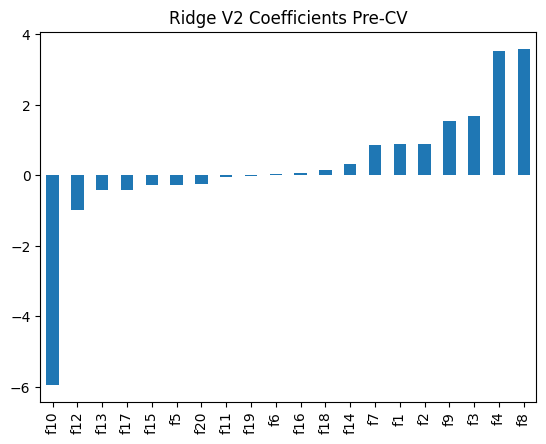

In [123]:
pd.Series(rr.coef_, features).sort_values(ascending = True).plot(kind = "bar", title = "Ridge V2 Coefficients Pre-CV")

<Axes: title={'center': 'Ridge V2 Coefficients post-CV'}>

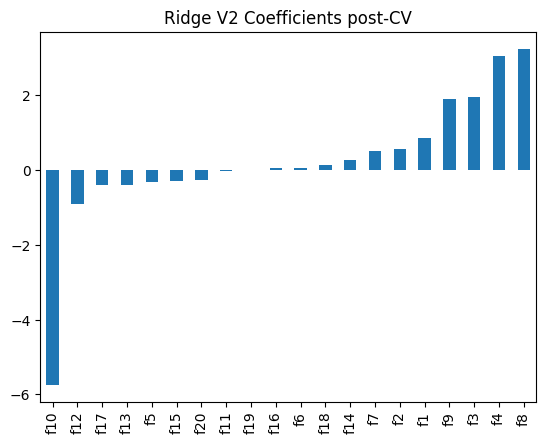

In [124]:
pd.Series(rr_cv.coef_, features).sort_values(ascending = True).plot(kind = "bar", title = "Ridge V2 Coefficients post-CV")

##Support Vector Regression - non-linear kernel  
SVMs try to find the hyperplane in a high-dimensional space that maximally separates different classes or output values.  

SVMs have 3 types of kernels: linear (more rigid and better for simple patterns), polynomial (has hyperparam degree), and non-linear RBF(Radial Basis Function) (more flexible and better for complex patterns), as well as sigmoid.

There are several hyperparameters aside from kernels, such as C and gamma. C controls the trade-off between insensitive and sensitive loss. Larger C : minimize insensitive loss (more flexible). Lower C : more lenient in allowing larger errors (less flexible).

Low gamma value : influence of a single training point reaches far, affecting a larger region of the feature space. High gamma : single data point influence is short, affecting only the region near the training example.  

The value of epsilon defines a margin of tolerance where no penalty is given to errors. The larger epsilon is, the larger errors I allow the modeling.

In [125]:
start = time.perf_counter() # start timer

svr = SVR(kernel='rbf') # init model with standard hyperparameters
svr.fit(x_train, y_train) # fit model
y_pred = svr.predict(x_val) # model predictions

end = time.perf_counter() # end timer
duration_nonCV_svr1 = end - start # calculate time elapsed

### Hyperparameter tuning grid search CV

In [126]:
start = time.perf_counter() # start timer

# Define the SVR model within a pipeline (including scaling)
svr_pipe = make_pipeline(SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1))

# Set up K-Fold Cross-Validation
# n_splits: number of folds (e.g., 5-fold cross-validation)
# shuffle: whether to shuffle the data before splitting
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define the hyperparameter grid. This defines the hyperparameter values to try out
# The "best" model will use some combination of the following values with the lowest
# error on validation data.
param_grid = {
    'svr__C': [135, 140, 145],
    'svr__epsilon': [0.16, 0.17, 0.15],
    'svr__gamma': [0.01, 0.003, 0.004]
}

grid_search = GridSearchCV(svr_pipe, param_grid, cv=kf, n_jobs=-1)
grid_search.fit(train.drop(columns=['target']), train['target'])
svr_best = grid_search.best_estimator_

end = time.perf_counter() # end timer
duration_CV_svr = end - start # calculate time elapsed

In [127]:
print("\nBest SVR parameters found by GridSearchCV:")
print(grid_search.best_params_)
print(f"\nBest mean R squared from GridSearchCV: {np.sqrt(grid_search.best_score_):.4f}")


Best SVR parameters found by GridSearchCV:
{'svr__C': 135, 'svr__epsilon': 0.15, 'svr__gamma': 0.003}

Best mean R squared from GridSearchCV: 0.8302


Visualizing Coefficients is very difficult with SVR rbf models, so we'll skip it for this one.

#**Evaluate models**

Assess the regression performance AND computational efficiency of the models you selected:

- Visualize the model fit to the training data. Using the models you created in part (c), plot the original data (as a scatter plot) AND the curves representing your models (each as a separate curve) from (c). One of these models should also be your BEST performing submission (based on evalutation using your test dataset). Label it as such.
- As you train and validate each model, time how long it takes to train and validate in each case and create a plot that shows both the training and prediction time for each model included.
- Describe:
  - Your process of model selection and hyperparameter tuning
  - Which model performed best and your process for identifying/selecting it

## Visualize Model fit to training data - all models

Define vectors of data for plotting  

including backtransforming the data from being scaled. use scaler.invers_transform(ypred)

In [128]:
ypreds = [lasso.predict(x_val), lasso_cv.predict(x_val), rr.predict(x_val), rr_cv.predict(x_val), svr.predict(x_val)]


## Plotting Runtime  
### Define vectors/arrays

In [129]:
fit_runtimes = [duration_nonCV_lasso1,
            duration_CV_lasso1,
            duration_nonCV_lasso2,
            duration_CV_lasso2,
            duration_nonCV_rr1,
            duration_CV_rr1,
            duration_nonCV_rr2,
            duration_CV_rr2,
            duration_nonCV_svr1,
            duration_CV_svr]

In [130]:
models = [lasso,
          lasso_cv,
          lasso2,
          lasso_cv2,
          rr,
          rr_cv,
          rr2,
          rr2_cv,
          svr,
          svr_best]

In [131]:
model_names = ['Lasso 1 No CV',
               'Lasso 1 CV',
               'Lasso 2 No CV',
               'Lasso 2 CV',
               'Ridge 1 No CV',
               'Ridge 1 CV',
               'Ridge 2 No CV',
               'Ridge 2 CV',
               'SVR No CV',
               'SVR CV'
               ]

### plot fitting runtimes

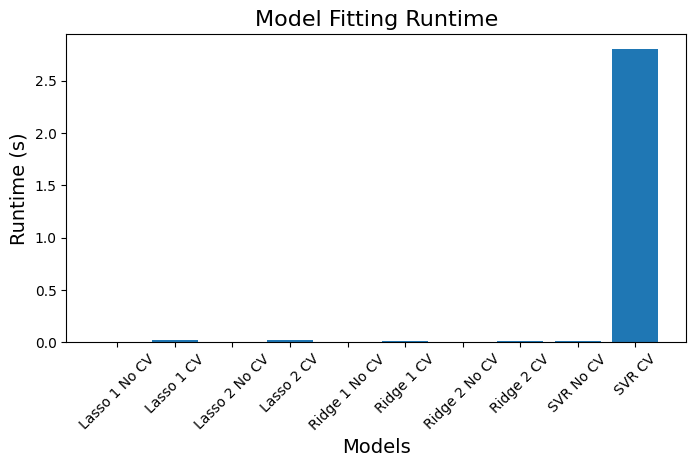

In [132]:
plt.figure(figsize=(8, 4))
plt.bar(x=model_names, height = fit_runtimes)
plt.title('Model Fitting Runtime', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Runtime (s)', fontsize=14)
plt.xticks(rotation=45)
plt.show()

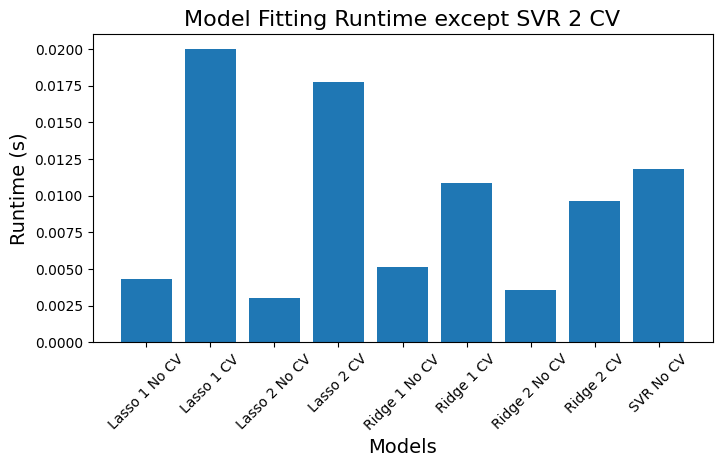

In [133]:
plt.figure(figsize=(8, 4))
plt.bar(x=model_names[:-1], height = fit_runtimes[:-1])
plt.title('Model Fitting Runtime except SVR 2 CV', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Runtime (s)', fontsize=14)
plt.xticks(rotation=45)
plt.show()

### Calculate predictions with runtimes

In [134]:
y_preds = []
pred_runtimes = []
mses = []
for model in models:
  print("start", model)
  start = time.perf_counter() # start timer
  y_preds.append(model.predict(x_val))
  end = time.perf_counter() # end timer
  pred_runtimes.append(end - start) # calculate time elapsed
  mses.append(mean_squared_error(y_val, y_preds[-1]))
  print("end", model)

start Lasso()
end Lasso()
start LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10], random_state=42)
end LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10], random_state=42)
start Lasso()
end Lasso()
start LassoCV(alphas=[0.05, 0.075, 0.1, 0.25, 0.5], random_state=42)
end LassoCV(alphas=[0.05, 0.075, 0.1, 0.25, 0.5], random_state=42)
start Ridge()
end Ridge()
start RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10], scoring='r2')
end RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10], scoring='r2')
start Ridge()
end Ridge()
start RidgeCV(alphas=[11, 12, 13, 14, 15], scoring='neg_mean_squared_error')
end RidgeCV(alphas=[11, 12, 13, 14, 15], scoring='neg_mean_squared_error')
start SVR()
end SVR()
start Pipeline(steps=[('svr', SVR(C=135, epsilon=0.15, gamma=0.003))])
end Pipeline(steps=[('svr', SVR(C=135, epsilon=0.15, gamma=0.003))])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


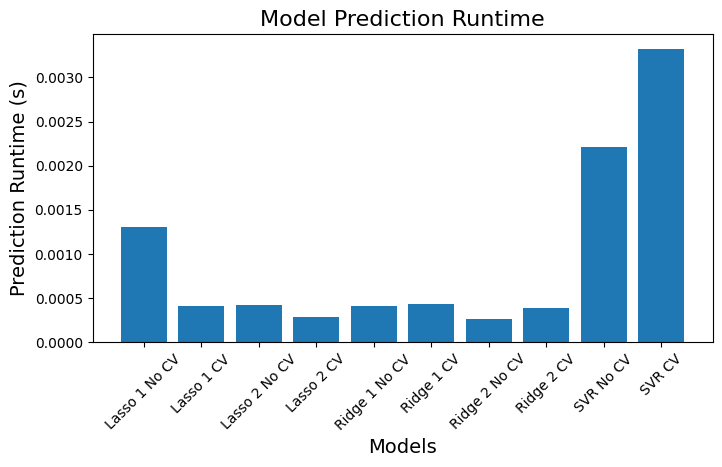

In [136]:
# plot prediction runtimes
plt.figure(figsize=(8, 4))
plt.bar(x=model_names, height = pred_runtimes)
plt.title('Model Prediction Runtime', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Prediction Runtime (s)', fontsize=14)
plt.xticks(rotation=45)
plt.show()

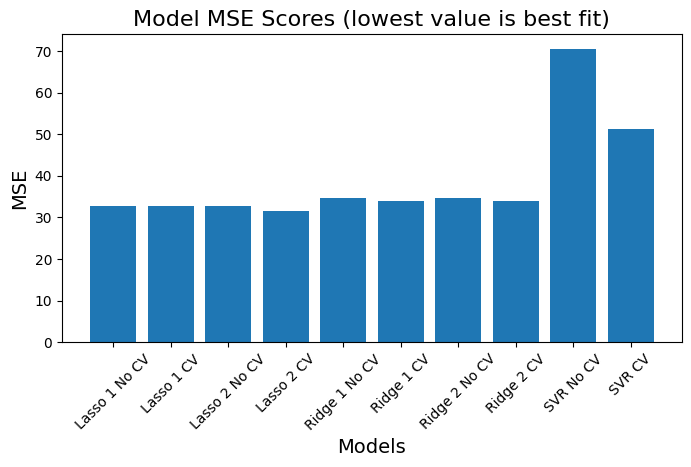

In [138]:
# plot MSE scores
plt.figure(figsize=(8, 4))
plt.bar(x=model_names, height = mses)
plt.title('Model MSE Scores (lowest value is best fit)', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('MSE', fontsize=14)
plt.xticks(rotation=45)
plt.show()

**(d) Apply your model "in practice".**  
Compare at least 5 different model results (using the test data provided). These do not need to be the same that you report on above, but you should select your *most competitive* models.
- Be sure to RETRAIN YOUR MODEL ON ALL LABELED TRAINING AND VALIDATION DATA before making your predictions on the test data for submission. This will help to maximize your performance on the test data.